In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import precision_recall_curve, roc_curve, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.4, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

rand_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rand_clf.fit(X_train, y_train)
y_pred_val = rand_clf.predict(X_val)
print(classification_report(y_val, y_pred_val))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        38
           1       0.96      1.00      0.98        76

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



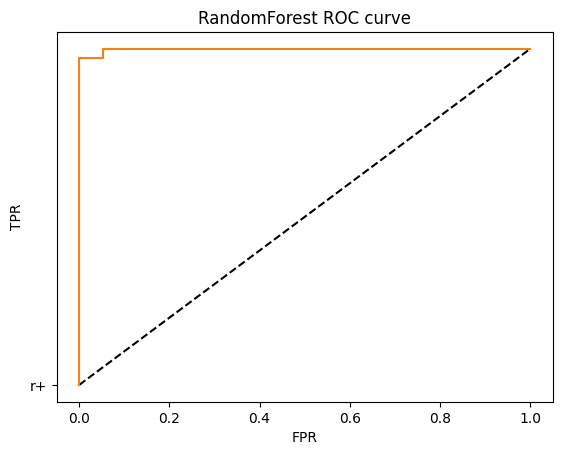

In [3]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
fpr, tpr, thresholds = roc_curve(y_val, rand_clf.predict_proba(X_val)[:,1])
plt.plot([0,1], [0,1], "k--", "r+")
plt.plot(fpr, tpr, label='RandomForest')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('RandomForest ROC curve')
plt.show()

In [4]:
from sklearn.metrics import roc_auc_score

rand_score = roc_auc_score(y_val, rand_clf.predict_proba(X_val)[:,1])
rand_score

0.9986149584487535